Assignment 10 — Gradient Descent Optimization

California Housing — Batch, Stochastic, Mini‑Batch

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
# Load dataset
data = fetch_california_housing()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [3]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
# Add bias term
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [5]:
# Batch Gradient Descent
lr = 0.01
epochs = 100
m, n = X_train.shape

theta = np.zeros(n)
costs = []

for i in range(epochs):
    pred = X_train.dot(theta)
    error = pred - y_train

    grad = (1/m) * X_train.T.dot(error)
    theta = theta - lr * grad

    cost = (1/(2*m)) * np.sum(error**2)
    costs.append(cost)

print("Training Done")

Training Done


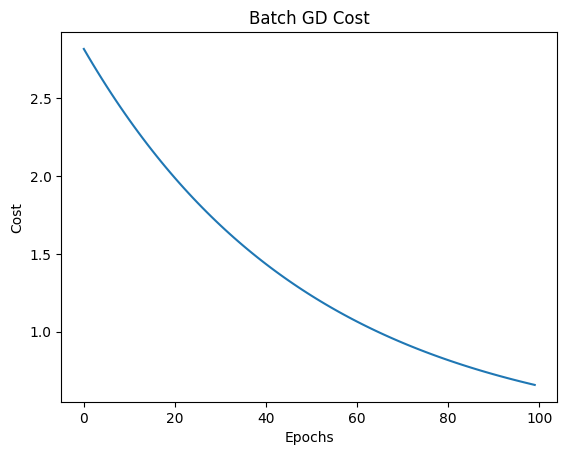

In [6]:
# Cost graph
plt.plot(costs)
plt.title("Batch GD Cost")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

In [7]:
# Prediction
pred_test = X_test.dot(theta)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print("RMSE:", rmse)

RMSE: 1.1386783400021694


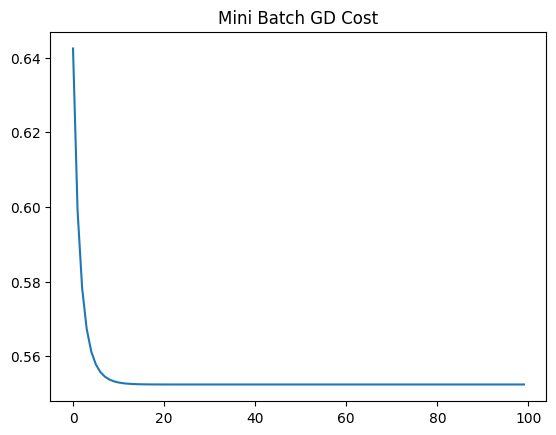

In [8]:
# Mini Batch Gradient Descent
theta2 = np.zeros(n)
cost2 = []

batch = 32

for i in range(epochs):
    for j in range(0, m, batch):
        Xb = X_train[j:j+batch]
        yb = y_train[j:j+batch]

        pred = Xb.dot(theta2)
        error = pred - yb

        grad = (1/len(Xb)) * Xb.T.dot(error)
        theta2 = theta2 - lr * grad

    c = np.mean(error**2)
    cost2.append(c)

plt.plot(cost2)
plt.title("Mini Batch GD Cost")
plt.show()

/tmp/ipykernel_20503/2945695562.py:16: RuntimeWarning: overflow encountered in square
  cost3.append(np.mean(error**2))


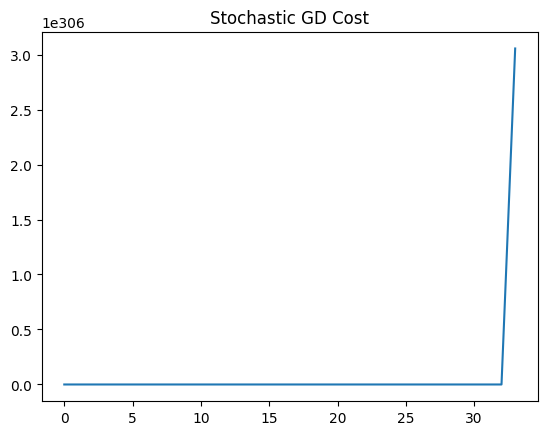

In [9]:
# Stochastic GD
theta3 = np.zeros(n)
cost3 = []

for i in range(epochs):
    for j in range(m):
        xi = X_train[j:j+1]
        yi = y_train[j]

        pred = xi.dot(theta3)
        error = pred - yi

        grad = xi.T.dot(error)
        theta3 = theta3 - lr * grad

    cost3.append(np.mean(error**2))

plt.plot(cost3)
plt.title("Stochastic GD Cost")
plt.show()

Conclusion:
Batch, Mini-batch, and Stochastic Gradient Descent were applied on California Housing dataset. Batch GD was stable but slower, Stochastic GD was faster but noisy, and Mini-batch gave balanced performance. Hence, Mini-batch GD is commonly preferred for optimization.